# 03 — EDA từ PostgreSQL

**Prerequisite**: Đã chạy `02_ingestion_api.ipynb` thành công.

**Run order**: `01a → 02_ingestion_api → 03_eda → 04_modeling → 05_evaluation`

In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import text

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)

PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / '.env')
from src.data.storage.postgres_client import get_engine

engine = get_engine()
print('[OK] Connected to PostgreSQL')

Matplotlib is building the font cache; this may take a moment.


2026-05-05 00:40:51 | INFO     | src.data.storage.postgres_client | PG engine created
[OK] Connected to PostgreSQL


In [2]:
# ── Load master_features từ PostgreSQL ────────────────────────────────────
with engine.connect() as conn:
    df = pd.read_sql("""
        SELECT * FROM features.master_features
        ORDER BY date
    """, conn, index_col='date', parse_dates=['date'])

print(f'[INFO] master_features shape: {df.shape}')
print(f'[INFO] Date range: {df.index.min().date()} → {df.index.max().date()}')
df.head(3)

[INFO] master_features shape: (0, 68)
[INFO] Date range: NaT → NaT


,gold_close,gold_open,gold_high,gold_low,gold_volume,sma_10,sma_20,sma_50,sma_100,sma_200,ema_10,ema_20,ema_50,ema_100,ema_200,bb_upper,bb_lower,bb_width,bb_pct,rsi_14,macd,macd_signal,macd_hist,roc_10,cci_20,stoch_k,stoch_d,adx_14,plus_di,minus_di,z_score_20,z_score_60,dxy_open,dxy_high,dxy_low,dxy_close,fed_funds_rate,us_interest_rate,us_10y_yield,us_inflation_yoy,cpi,core_cpi,breakeven_inflation,us_2y_yield,us_30y_yield,yield_curve_slope,m2_money_supply,unemployment_rate,vix,sp500_close,silver_close,wti_oil_price,brent_oil_price,gold_silver_ratio,gold_oil_ratio,gold_sp500_ratio,gold_dxy_ratio,real_yield,oil_spread,gold_avg_5d,gold_pct_chg_5d,gold_avg_21d,gold_pct_chg_21d,gold_avg_63d,gold_pct_chg_63d,gold_avg_252d,gold_pct_chg_252d,updated_at
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,


In [3]:
# ── Missing values ────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(f'Columns with missing values: {len(missing_df)}')
print(missing_df.head(20))

Columns with missing values: 0
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []


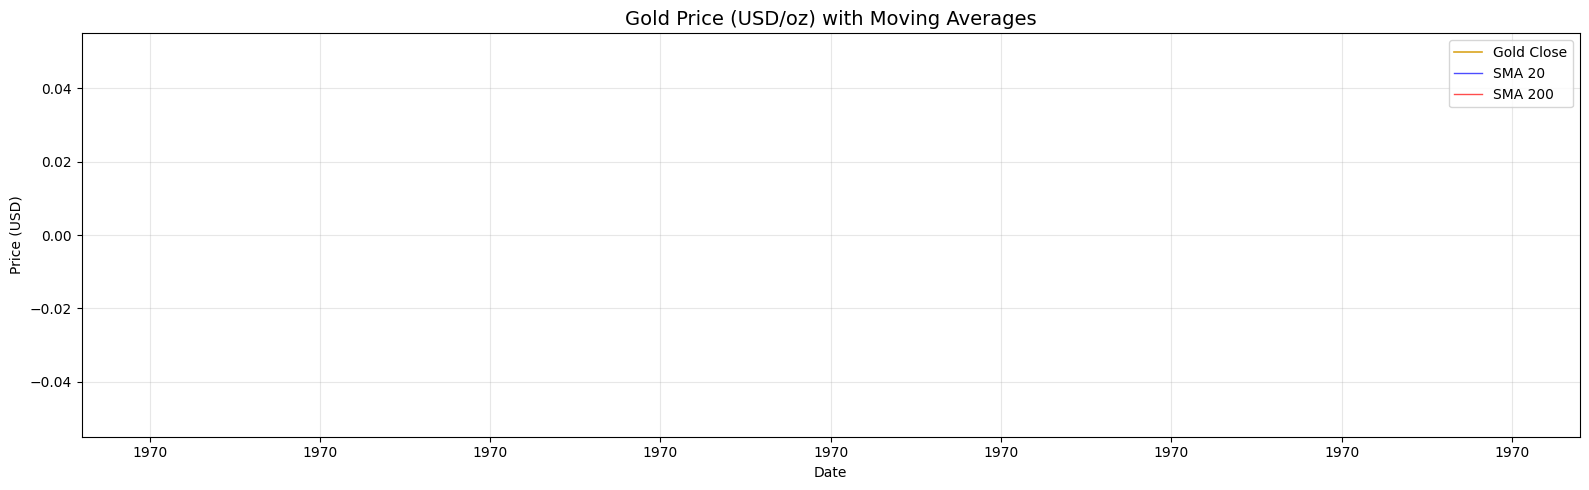

In [4]:
# ── Gold price time series ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df.index, df['gold_close'], lw=1.2, color='goldenrod', label='Gold Close')
if 'sma_20' in df.columns:
    ax.plot(df.index, df['sma_20'], lw=1, color='blue', alpha=0.7, label='SMA 20')
if 'sma_200' in df.columns:
    ax.plot(df.index, df['sma_200'], lw=1, color='red', alpha=0.7, label='SMA 200')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Gold Price (USD/oz) with Moving Averages', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# ── Bollinger Bands (last 2 years) ─────────────────────────────────────────
df_recent = df.last('2Y').copy()
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_recent.index, df_recent['gold_close'], lw=1.2, color='goldenrod', label='Gold Close')
if 'bb_upper' in df_recent.columns:
    ax.plot(df_recent.index, df_recent['bb_upper'], lw=1, color='gray', linestyle='--', label='BB Upper')
    ax.plot(df_recent.index, df_recent['bb_lower'], lw=1, color='gray', linestyle='--', label='BB Lower')
    ax.fill_between(df_recent.index, df_recent['bb_lower'], df_recent['bb_upper'], alpha=0.1, color='gray')
ax.set_title('Bollinger Bands (Last 2 Years)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'last'

In [ ]:
# ── RSI and MACD ──────────────────────────────────────────────────────────
df_recent = df.last('1Y').copy()
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# Gold price
axes[0].plot(df_recent.index, df_recent['gold_close'], color='goldenrod')
axes[0].set_title('Gold Close')
axes[0].grid(True, alpha=0.3)

# RSI
if 'rsi_14' in df_recent.columns:
    axes[1].plot(df_recent.index, df_recent['rsi_14'], color='purple')
    axes[1].axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
    axes[1].axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
    axes[1].set_title('RSI (14)')
    axes[1].set_ylim(0, 100)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

# MACD
if 'macd' in df_recent.columns:
    axes[2].plot(df_recent.index, df_recent['macd'], color='blue', label='MACD')
    axes[2].plot(df_recent.index, df_recent['macd_signal'], color='red', label='Signal')
    if 'macd_hist' in df_recent.columns:
        axes[2].bar(df_recent.index, df_recent['macd_hist'], color='gray', alpha=0.3, label='Histogram')
    axes[2].axhline(0, color='black', lw=0.5)
    axes[2].set_title('MACD (12, 26, 9)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ── Macro factors vs Gold ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

macro_pairs = [
    ('dxy_close', 'DXY Index', 'steelblue'),
    ('us_10y_yield', 'US 10Y Yield (%)', 'firebrick'),
    ('real_yield', 'Real Yield (%)', 'darkorange'),
    ('vix', 'VIX', 'darkgreen'),
]

for ax, (col, label, color) in zip(axes.flat, macro_pairs):
    if col in df.columns:
        ax2 = ax.twinx()
        ax.plot(df.index, df['gold_close'], color='goldenrod', lw=1, alpha=0.7, label='Gold')
        ax2.plot(df.index, df[col], color=color, lw=1, alpha=0.7, label=label)
        ax.set_title(f'Gold vs {label}')
        ax.set_ylabel('Gold (USD)', color='goldenrod')
        ax2.set_ylabel(label, color=color)
        ax.grid(True, alpha=0.3)

plt.suptitle('Macro Factors vs Gold Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Gold ratios ────────────────────────────────────────────────────────────
ratio_cols = ['gold_silver_ratio', 'gold_oil_ratio', 'gold_sp500_ratio', 'gold_dxy_ratio']
ratio_cols = [c for c in ratio_cols if c in df.columns]

fig, axes = plt.subplots(1, len(ratio_cols), figsize=(16, 4))
for ax, col in zip(axes, ratio_cols):
    ax.plot(df.index, df[col], lw=1)
    ax.set_title(col.replace('_', ' ').title())
    ax.grid(True, alpha=0.3)

plt.suptitle('Gold Cross-Asset Ratios', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Correlation heatmap ────────────────────────────────────────────────────
# Load target labels
with engine.connect() as conn:
    df_targets = pd.read_sql("""
        SELECT date, next_1_day_price_change, next_7_day_price_change, next_30_day_price_change
        FROM features.target_labels
        WHERE next_1_day_price_change IS NOT NULL
        ORDER BY date
    """, conn, index_col='date', parse_dates=['date'])

df_combined = df.join(df_targets, how='inner')

# Select key features for correlation
key_features = [
    'gold_close', 'sma_20', 'rsi_14', 'macd', 'adx_14',
    'dxy_close', 'us_10y_yield', 'real_yield', 'vix',
    'gold_silver_ratio', 'gold_oil_ratio',
    'gold_pct_chg_5d', 'gold_pct_chg_21d',
    'next_1_day_price_change'
]
key_features = [f for f in key_features if f in df_combined.columns]

corr = df_combined[key_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

# Correlation với target
print('\n=== Top features correlated with next_1_day_price_change ===')
target_corr = corr['next_1_day_price_change'].drop('next_1_day_price_change').abs().sort_values(ascending=False)
print(target_corr)

In [ ]:
# ── Sliding window statistics ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

windows = [
    ('gold_pct_chg_5d', 'Weekly Return % (5d)'),
    ('gold_pct_chg_21d', 'Monthly Return % (21d)'),
    ('gold_pct_chg_63d', 'Quarterly Return % (63d)'),
    ('gold_pct_chg_252d', 'Yearly Return % (252d)'),
]

for ax, (col, title) in zip(axes.flat, windows):
    if col in df.columns:
        data = df[col].dropna()
        ax.hist(data, bins=50, edgecolor='white', color='steelblue', alpha=0.8)
        ax.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}%')
        ax.axvline(0, color='black', lw=0.8)
        ax.set_title(title)
        ax.set_xlabel('Return %')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.suptitle('Gold Return Distribution by Time Window', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Target label statistics ────────────────────────────────────────────────
with engine.connect() as conn:
    df_all_targets = pd.read_sql("""
        SELECT *
        FROM features.target_labels
        WHERE next_1_day_price IS NOT NULL
        ORDER BY date
    """, conn, index_col='date', parse_dates=['date'])

print('=== Target Labels Statistics ===')
print(df_all_targets.describe().T)

# Direction distribution
for horizon in [1, 3, 7, 30]:
    col = f'next_{horizon}_day_direction'
    if col in df_all_targets.columns:
        up = df_all_targets[col].sum()
        total = df_all_targets[col].count()
        print(f'Next {horizon:2d}d UP: {up/total*100:.1f}% | DOWN: {(1 - up/total)*100:.1f}% | N={total}')